In [9]:
import pandas as pd

## Data Loading

In [10]:
ipl2022 = pd.read_csv('../data/ipl_2022_deliveries.csv')
ipl2023 = pd.read_csv('../data/ipl_2023_deliveries.csv')
ipl2024 = pd.read_csv('../data/ipl_2024_deliveries.csv')
ipl2025 = pd.read_csv('../data/ipl_2025_deliveries.csv')
ipl2026 = pd.read_csv('../data/ipl_2026_deliveries.csv')

In [11]:
mergedData = pd.concat([ipl2022,ipl2023,ipl2024,ipl2025, ipl2026], ignore_index=True)

## Data Cleaning


In [13]:
mergedData.drop(columns=['striker','bowler','player_dismissed','fielder','date','match_id','venue','phase'],inplace=True,axis=0)

In [14]:
mergedData.head()

,season,match_no,batting_team,bowling_team,innings,over,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type
0,2022,1,CSK,KKR,1,0.1,0,1,0,0,0,1,NaN
1,2022,1,CSK,KKR,1,0.1,0,0,0,0,0,0,NaN
2,2022,1,CSK,KKR,1,0.2,0,1,1,0,0,0,NaN
3,2022,1,CSK,KKR,1,0.2,0,0,0,0,0,0,NaN
4,2022,1,CSK,KKR,1,0.3,0,0,0,0,0,0,caught


In [15]:
mergedData = mergedData[mergedData.innings == 1]

In [16]:
mergedData['totalRuns'] = mergedData['runs_of_bat'] + mergedData['extras']

In [17]:
mergedData.shape

(45260, 14)

In [18]:
##RAIN AFFECTED MATCHES
legalDeliveries = mergedData[
    (mergedData['wide'] == 0) &
    (mergedData['noballs'] == 0)
]

legalDeliveriesCount = legalDeliveries.groupby(
    ['season', 'match_no', 'innings']
).size().reset_index(name='legalDeliveriesCount')

wickets = mergedData[
    mergedData['wicket_type'].notna()
]
wicketCount = wickets.groupby(
    ['season', 'match_no', 'innings']
).size().reset_index(name='wickets')

inningsSummary = legalDeliveriesCount.merge(
    wicketCount,
    on=['season', 'match_no', 'innings'],
    how='left'
)

inningsSummary['wickets'] = inningsSummary['wickets'].fillna(0)

rainAffected = inningsSummary[
    (inningsSummary['legalDeliveriesCount'] < 120) &
    (inningsSummary['wickets'] < 10)
]
rainAffected

,season,match_no,innings,legalDeliveriesCount,wickets
118,2023,45,1,116,7.0
205,2024,60,1,96,7.0
250,2025,34,1,84,9.0
274,2025,58,1,61,1.0
302,2026,12,1,22,2.0
303,2026,13,1,66,3.0
326,2026,36,1,119,6.0
340,2026,50,1,114,3.0


In [71]:
mergedData.shape

(26932, 14)

In [19]:

##DROPPING THE RAIN AFFECTED FIRST INNINGS WHERE TOTAL BALL BOWLED WERE LESS THAN 100
mergedData.drop(
    mergedData[
        (mergedData['match_no'] == 34) &
        (mergedData['season'] == 2025)
    ].index,
    inplace=True
)

mergedData.drop(
    mergedData[
        (mergedData['match_no'] == 60) &
        (mergedData['season'] == 2024)
    ].index,
    inplace=True
)


mergedData.drop(
    mergedData[
        (mergedData['match_no'] == 12) &
        (mergedData['season'] == 2026)
    ].index,
    inplace=True
)

mergedData.drop(
    mergedData[
        (mergedData['match_no'] == 13) &
        (mergedData['season'] == 2026)
    ].index,
    inplace=True
)

mergedData.drop(
    mergedData[
        (mergedData['match_no'] == 58) &
        (mergedData['season'] == 2025)
    ].index,
    inplace=True
)

## Feature Engineering

In [20]:
inningsScores = (
    mergedData
    .groupby(['season', 'match_no', 'batting_team'])['totalRuns']
    .sum()
)
inningsScores.groupby('batting_team').mean().sort_values(ascending=False)

batting_team
SRH     197.078947
RCB     189.512195
KKR     186.781250
GT      186.147059
PBKS    185.405405
LSG     185.365854
RR      184.315789
CSK     181.536585
MI      180.064516
DC      178.666667
Name: totalRuns, dtype: float64

In [21]:
##FINDING AVERGAGE POWERPLAY SCORES OVER THE LAST 5 YEARS
powerplayScore =mergedData[mergedData.over<=6].groupby(['season','match_no','batting_team'])['totalRuns'].sum()
powerplayScore
powerplayScore.groupby('batting_team').mean().sort_values(ascending=False)

batting_team
SRH     60.315789
PBKS    56.837838
KKR     55.343750
RR      54.684211
RCB     53.780488
DC      53.037037
MI      52.806452
CSK     52.292683
LSG     52.073171
GT      51.382353
Name: totalRuns, dtype: float64

In [22]:
powerplayWickets = mergedData[(mergedData.over<=6) & (mergedData.wicket_type.notnull())].groupby(['season','match_no','batting_team'])['wicket_type'].size()
powerplayWickets
powerplayWickets.groupby('batting_team').mean().sort_values(ascending=False)
mergedData[mergedData.extras>1]


,season,match_no,batting_team,bowling_team,innings,over,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,totalRuns
482,2022,3,RCB,PBKS,1,1.1,0,5,1,0,0,0,NaN,5
484,2022,3,RCB,PBKS,1,1.2,0,4,0,1,0,0,NaN,4
519,2022,3,RCB,PBKS,1,6.5,0,4,0,0,1,0,NaN,4
538,2022,3,RCB,PBKS,1,9.6,0,2,1,0,0,0,NaN,2
1286,2022,6,KKR,RCB,1,9.3,0,2,0,0,1,0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84984,2026,66,GT,CSK,1,13.6,0,2,1,0,0,0,NaN,2
85113,2026,67,SRH,RCB,1,0.2,0,2,1,0,0,0,NaN,2
85651,2026,69,RR,MI,1,7.3,0,3,1,0,0,0,NaN,3
86472,2026,72,RR,SRH,1,19.6,0,2,0,0,1,0,NaN,2


In [23]:
## CREATING AN NEW DATFRAME
inningsData = pd.DataFrame({
    'Final Score': inningsScores,
    'PP runs': powerplayScore,
    'PP wickets': powerplayWickets
})
inningsData['PP wickets'] = inningsData['PP wickets'].fillna(0)
inningsData.shape

(360, 3)

In [24]:
mergedData.shape

(44919, 14)

In [25]:
## dotBallPerecntage = (noOfDotBalls/noOfLegalDeliveries)*100

legalDeliveries = mergedData[(mergedData.noballs==0)& (mergedData.wide==0) &(mergedData.over<=6)]
totalLegalDeliveries = legalDeliveries.groupby(['season','match_no','batting_team']).size()
dotBall = legalDeliveries[(legalDeliveries.totalRuns==0) & (legalDeliveries.over<=6)].groupby(['season','match_no','batting_team']).size()
(dotBall/totalLegalDeliveries)*100
inningsData['dotBallPercentage'] = (dotBall/totalLegalDeliveries)*100
# dotBall

In [26]:
## boundaryPercentage = (noOfBoundaries/noOfLegalDeliveries)*100

boundaryPercentage = legalDeliveries[((legalDeliveries.runs_of_bat==4) | (legalDeliveries.runs_of_bat==6)) & (legalDeliveries.over<=6)].groupby(['season','match_no','batting_team']).size()
(boundaryPercentage/totalLegalDeliveries)*100
inningsData['boundaryPercentage'] = (boundaryPercentage/totalLegalDeliveries)*100
inningsData.head()

Final Score  PP runs  PP wickets  \
season match_no batting_team                                     
2022   1        CSK                   131       35         2.0   
       2        MI                    177       53         0.0   
       3        RCB                   205       41         0.0   
       4        LSG                   158       32         4.0   
       5        RR                    210       58         0.0   

                              dotBallPercentage  boundaryPercentage  
season match_no batting_team                                         
2022   1        CSK                   63.888889           13.888889  
       2        MI                    50.000000           25.000000  
       3        RCB                   58.333333           11.111111  
       4        LSG                   58.333333           11.111111  
       5        RR                    55.555556           22.222222

In [27]:
finalInningsData = inningsData.reset_index()
finalInningsData.head(10)
finalInningsData.dtypes

season                  int64
match_no                int64
batting_team              str
Final Score             int64
PP runs                 int64
PP wickets            float64
dotBallPercentage     float64
boundaryPercentage    float64
dtype: object

## Exploratory Data Analysis

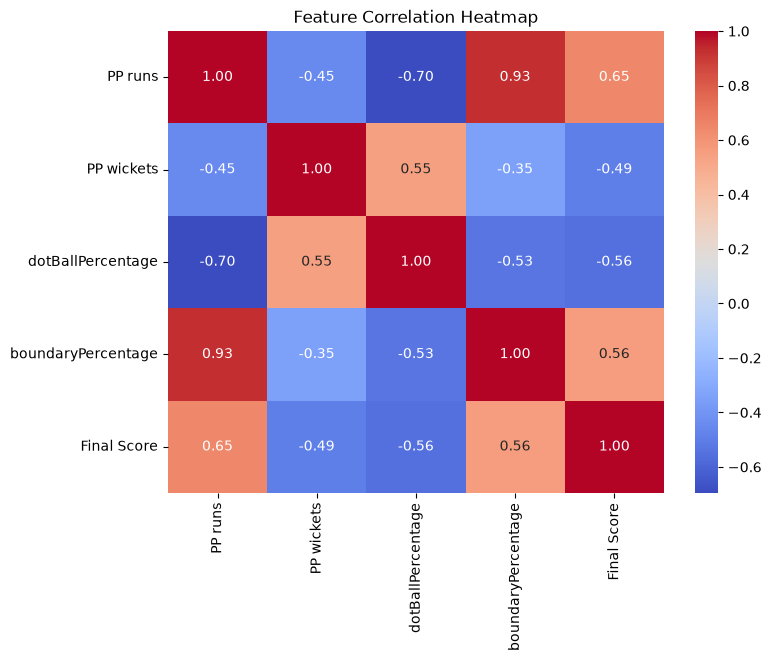

In [61]:
finalInningsData.corr(numeric_only=True)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    finalInningsData[
        ['PP runs',
         'PP wickets',
         'dotBallPercentage',
         'boundaryPercentage',
         'Final Score']
    ].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [29]:
##ONE HOT ENCODING FOR BATSMAN TEAM
finalInningsData = pd.get_dummies(finalInningsData, columns=['batting_team'],dtype=int,drop_first=True)


In [30]:
finalInningsData.columns

Index(['season', 'match_no', 'Final Score', 'PP runs', 'PP wickets',
       'dotBallPercentage', 'boundaryPercentage', 'batting_team_DC',
       'batting_team_GT', 'batting_team_KKR', 'batting_team_LSG',
       'batting_team_MI', 'batting_team_PBKS', 'batting_team_RCB',
       'batting_team_RR', 'batting_team_SRH'],
      dtype='str')

In [31]:
import matplotlib.pyplot as plt

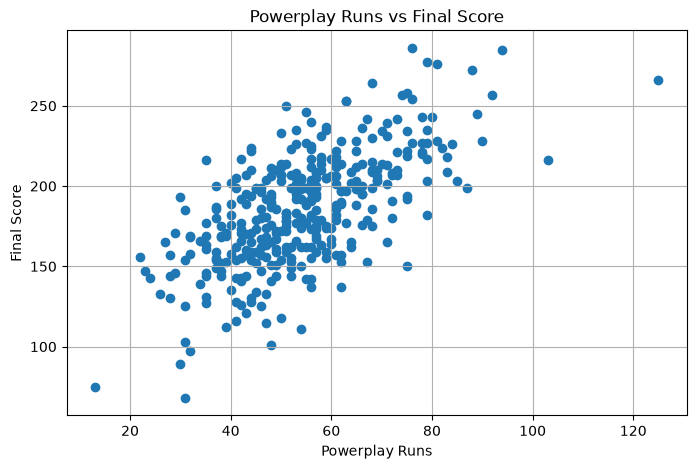

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(finalInningsData['PP runs'], finalInningsData['Final Score'])
plt.xlabel('Powerplay Runs')
plt.ylabel('Final Score')
plt.title('Powerplay Runs vs Final Score')
plt.grid(True)
plt.savefig("../images/pp_runs_vs_score.png", dpi=300, bbox_inches="tight")
plt.show()

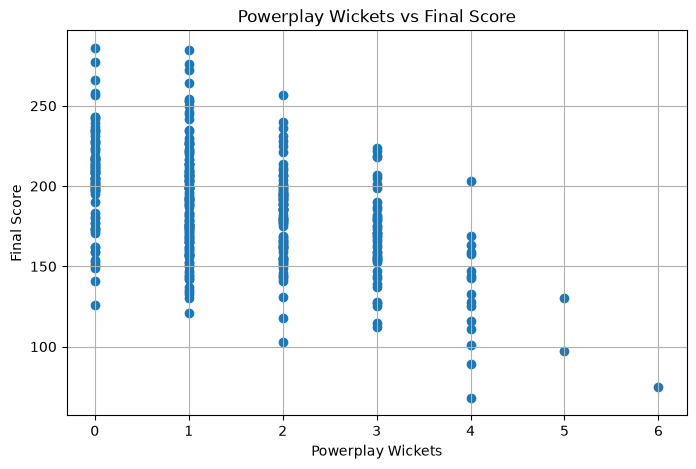

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(inningsData['PP wickets'], inningsData['Final Score'])
plt.xlabel('Powerplay Wickets')
plt.ylabel('Final Score')
plt.title('Powerplay Wickets vs Final Score')
plt.grid(True)
plt.savefig("../images/pp_wickets_vs_score.png", dpi=300, bbox_inches="tight")
plt.show()

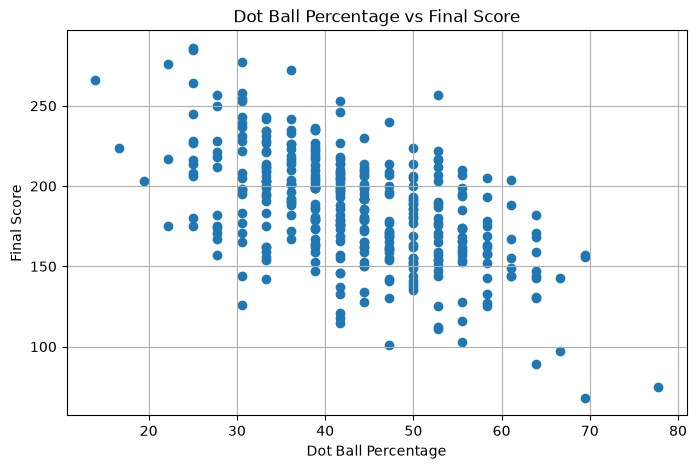

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(inningsData['dotBallPercentage'], inningsData['Final Score'])
plt.xlabel('Dot Ball Percentage')
plt.ylabel('Final Score')
plt.title('Dot Ball Percentage vs Final Score')
plt.grid(True)
plt.savefig("../images/dot_balls_vs_score.png", dpi=300, bbox_inches="tight")
plt.show()

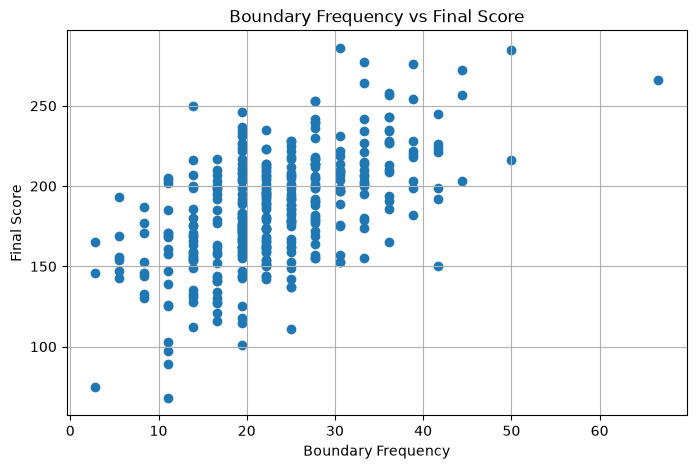

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(inningsData['boundaryPercentage'], inningsData['Final Score'])
plt.xlabel('Boundary Frequency')
plt.ylabel('Final Score')
plt.title('Boundary Frequency vs Final Score')
plt.grid(True)
plt.savefig("../images/boundaries_vs_score.png", dpi=300, bbox_inches="tight")
plt.show()

## Linear Regression
### 1: First with PP runs
### 2: Included PP wickets 
### 3: Included Dot Ball% 
### 4: Included Boundary%
### 5: Included batting teams
### 6: Included Season and excluded batting team

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
## Only including powerplay runs as the input feature
X = finalInningsData[['PP runs']]
Y= finalInningsData['Final Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)

In [38]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values("Coefficient", ascending=False))

   Feature  Coefficient
0  PP runs     1.642448


In [39]:
mae = mean_absolute_error(Y_test, y_pred)

rmse = mean_squared_error(Y_test, y_pred) ** 0.5

r2 = r2_score(Y_test, y_pred)
print(mae, rmse, r2)

21.740644326881306 27.19795327730919 0.39769674691838663


In [40]:
comparison = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": y_pred
})

print(comparison.head(10))

     Actual   Predicted
224     195  204.375096
42      170  166.598787
285     227  225.726923
302     216  265.145680
56      144  153.459201
272     218  191.235510
15      189  166.598787
57      160  166.598787
248     162  171.526131
124     227  224.084474


In [42]:
X = finalInningsData[['PP runs', 'PP wickets']]
Y= finalInningsData['Final Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)

In [43]:
mae = mean_absolute_error(Y_test, y_pred)

rmse = mean_squared_error(Y_test, y_pred) ** 0.5

r2 = r2_score(Y_test, y_pred)
print(mae, rmse, r2)

22.157214195461236 26.2473613971979 0.43906303010947334


In [44]:
X = finalInningsData[['PP runs', 'PP wickets','dotBallPercentage']]
Y= finalInningsData['Final Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)

In [45]:
mae = mean_absolute_error(Y_test, y_pred)

rmse = mean_squared_error(Y_test, y_pred) ** 0.5

r2 = r2_score(Y_test, y_pred)
print(mae, rmse, r2)

22.568663444240045 26.73655192696224 0.41795902736905644


In [46]:
X = finalInningsData[['PP runs', 'PP wickets','dotBallPercentage', 'boundaryPercentage']]
Y= finalInningsData['Final Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)

In [47]:
mae = mean_absolute_error(Y_test, y_pred)

rmse = mean_squared_error(Y_test, y_pred) ** 0.5

r2 = r2_score(Y_test, y_pred)
print(mae, rmse, r2)

22.56389969467213 26.715552077444766 0.4188729801307235


In [48]:
X = finalInningsData[['PP runs', 'PP wickets','dotBallPercentage', 'batting_team_DC', 'batting_team_GT', 'batting_team_KKR', 'batting_team_LSG', 'batting_team_MI', 'batting_team_PBKS', 'batting_team_RR', 'batting_team_SRH','batting_team_RCB']]
Y= finalInningsData['Final Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)

In [49]:
## Now adding season also as it may affect the total first innings score. Doing one hot encoding for season

dataIncludingSeason = pd.get_dummies(finalInningsData, columns=['season'],dtype=int,drop_first=True)


In [ ]:

X = dataIncludingSeason[['PP runs', 'PP wickets','dotBallPercentage', 'season_2023','season_2024','season_2025','season_2026']]
Y= dataIncludingSeason['Final Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)

In [51]:
mae = mean_absolute_error(Y_test, y_pred)

rmse = mean_squared_error(Y_test, y_pred) ** 0.5

r2 = r2_score(Y_test, y_pred)
print(mae, rmse, r2)

21.89225859643124 26.077163105334485 0.44631411934136955


## Random Forest

In [52]:
## Now using the RandomForest model
from sklearn.ensemble import RandomForestRegressor



In [ ]:
X = dataIncludingSeason[['PP runs', 'PP wickets','dotBallPercentage', 'boundaryPercentage','season_2023','season_2024','season_2025','season_2026']]
Y = dataIncludingSeason['Final Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=500,max_depth=3,random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

In [54]:
mae = mean_absolute_error(Y_test, y_pred)

rmse = mean_squared_error(Y_test, y_pred) ** 0.5

r2 = r2_score(Y_test, y_pred)
print(mae, rmse, r2)

21.42042668633713 25.87007198630982 0.45507336434207657


In [55]:
print(model.score(X_train, Y_train))
print(model.score(X_test, Y_test))

0.5429372236285045
0.45507336434207657


## XG Boost

In [56]:
## Now using xgBoost
from xgboost import XGBRegressor


In [57]:
X = dataIncludingSeason[['PP runs', 'PP wickets','dotBallPercentage', 'boundaryPercentage','season_2023','season_2024','season_2025','season_2026']]
Y = dataIncludingSeason['Final Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = XGBRegressor(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

In [58]:
mae = mean_absolute_error(Y_test, y_pred)

rmse = mean_squared_error(Y_test, y_pred) ** 0.5

r2 = r2_score(Y_test, y_pred)
print(mae, rmse, r2)

22.17409896850586 26.482182108698694 0.42898130416870117


In [59]:
print(model.score(X_train, Y_train))
print(model.score(X_test, Y_test))

0.4941450357437134
0.42898130416870117


## Model Comparison

In [67]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression (PP Runs)",
        "Linear Regression (+ PP Wickets)",
        "Linear Regression (+ Dot Ball %)",
        "Linear Regression (+ Boundary %)",
         "Linear Regression (+ Batting Team %)",
        "Linear Regression (+ Season)",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        21.74,
        22.16,
        22.57,
        22.56,
        22.96,
        21.89,
        21.35,      
        22.17       
    ],
    "RMSE": [
        27.20,
        26.25,
        26.74,
        26.72,
        27.30,
        26.08,
        25.72,      
        26.48       
    ],
    "R2 Score": [
        0.398,
        0.439,
        0.418,
        0.419,
        0.393,
        0.446,
        0.461,      
        0.429       
    ]
})

print(results)

# Save to CSV
results.to_csv("../results/model_comparison.csv", index=False)

                                  Model    MAE   RMSE  R2 Score
0           Linear Regression (PP Runs)  21.74  27.20     0.398
1      Linear Regression (+ PP Wickets)  22.16  26.25     0.439
2      Linear Regression (+ Dot Ball %)  22.57  26.74     0.418
3      Linear Regression (+ Boundary %)  22.56  26.72     0.419
4  Linear Regression (+ Batting Team %)  22.96  27.30     0.393
5          Linear Regression (+ Season)  21.89  26.08     0.446
6                         Random Forest  21.35  25.72     0.461
7                               XGBoost  22.17  26.48     0.429


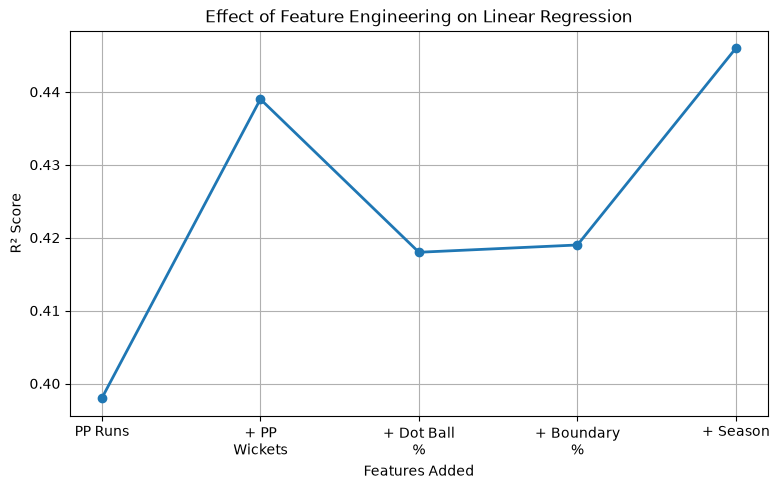

In [64]:
features = [
    "PP Runs",
    "+ PP\nWickets",
    "+ Dot Ball\n%",
    "+ Boundary\n%",
    "+ Season"
]

r2 = [0.398, 0.439, 0.418, 0.419, 0.446]

plt.figure(figsize=(9,5))
plt.plot(features, r2, marker="o", linewidth=2)

plt.title("Effect of Feature Engineering on Linear Regression")
plt.xlabel("Features Added")
plt.ylabel("R² Score")
plt.grid(True)

plt.savefig("../images/feature_progression.png", dpi=300, bbox_inches="tight")

plt.show()

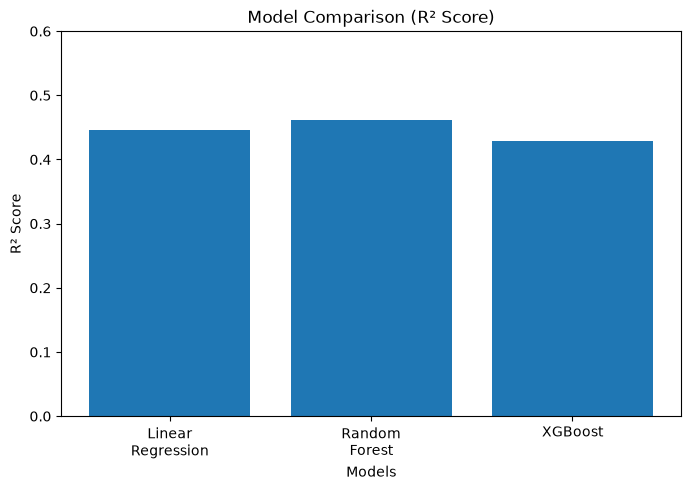

In [66]:
import matplotlib.pyplot as plt

models = [
    "Linear\nRegression",
    "Random\nForest",
    "XGBoost"
]

r2_scores = [
    0.446,
    0.461,
    0.429
]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xlabel("Models")
plt.ylim(0, 0.6)

plt.savefig("../images/model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()